# Conceptual

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
import statsmodels.api as sm

## Q1.
```{admonition}
:class: note
Suppose we test $m$ null hypotheses, all of which are true. We control the Type I error for each null hypothesis at level $\alpha$.

```{admonition}
:class: note
(a) In total, how many Type I errors do we expect to make?

$\alpha m$.

```{admonition}
:class: note
(b) Suppose that the $m$ tests that we perform are independent. What is the family-wise error rate associated with these $m$ tests?

$1-(1-\alpha)^{m}$.

```{admonition}
:class: note
(c) Suppose that $m = 2$, and that the $p$-values for the two tests are positively correlated, so that if one is small then the other will tend to be small as well, and if one is large then the other will tend to be large. How does the family-wise error rate associated with these $m = 2$ tests qualitatively compare to the answer in (b) with $m = 2$?

Suppose in fact $p_{1} = p_{2}$. Then the family-wise error rate is
$$
\operatorname{Pr}(V=1)+\operatorname{Pr}(V=2) = 0+\alpha = \alpha,
$$
since the probability of only having one error is $0$ while having two is $\alpha$ given the dependence. This is compared to
$$
1-(1-\alpha)^{2} = 1-(1-2\alpha+\alpha^{2}) = 2\alpha-\alpha^{2} = \alpha(2-\alpha)
$$
and we see that in this case the family-wise error rate is less than or equal to the independence assumption from (b).

```{admonition}
:class: note
(d) Suppose again that $m = 2$, but that now the $p$-values for the two tests are negatively correlated, so that if one is large then the other will tend to be small. How does the family-wise error rate associated with these $m = 2$ tests qualitatively compare to the answer in (b) with $m = 2$?

The family-wise error rate is
\begin{align*}
\operatorname{Pr}(\{\text{falsely reject }H_{00}\}\cup\{\text{falsely reject }H_{01}\})
&= \operatorname{Pr}(\{\text{falsely reject }H_{00}\})+\operatorname{Pr}(\{\text{falsely reject }H_{01}\})-\operatorname{Pr}(\{\text{falsely reject }H_{00}\}\cap\{\text{falsely reject }H_{01}\})\\
&= 2\alpha-\operatorname{Pr}(\{\text{falsely reject }H_{00}\}\cap\{\text{falsely reject }H_{01}\}).
\end{align*}
 
This intersection can range from $0$ to $\alpha^{2}$, so is always greater than or equal to the independent assumption in (b).

Note that in the extreme case where if one is rejected the other is not rejected, so the intersection probability is $0$, we have $\alpha < 0.5$ as otherwise these events cannot be disjoint.

## Q2.
```{admonition}
:class: note
Suppose that we test $m$ hypotheses, and control the Type I error for each hypothesis at level $\alpha$. Assume that all $m$ $p$-values are independent, and that all null hypotheses are true.

```{admonition}
:class: note
(a) Let the random variable $A_{j}$ equal $1$ if the $j$th null hypothesis is rejected, and $0$ otherwise. What is the distribution of $A_{j}$?

$A_{j}$ is Bernoulli distributed with probability $\alpha$.

```{admonition}
:class: note
(b) What is the distribution of $\sum_{j=1}^{m} A_{j}$?

The sum of $m$ independent identically distributed Bernoulli variables is a binomial random variable $\operatorname{B}(m,\alpha)$.

```{admonition}
:class: note
(c) What is the standard deviation of the number of Type I errors that we will make?

The standard deviation of $\operatorname{B}(n,\alpha)$ is $\sqrt{m\alpha(1-\alpha)}$.

## Q3.
```{admonition}
:class: note
Suppose we test $m$ null hypotheses, and control the Type I error for the $j$th null hypothesis at level $\alpha_{j}$, for $j = 1, \dots , m$. Argue that the family-wise error rate is no greater than $\sum_{j=1}^{m}\alpha_{j}$.

The family-wise error rate is
$$
\operatorname{Pr}\left(\bigcup_{j=1}^{m}\{\text{falsely reject }H_{0j}\}\right)
$$
and probabilities are subadditive so we have
$$
\operatorname{Pr}\left(\bigcup_{j=1}^{m}\{\text{falsely reject }H_{0j}\}\right) \leq \sum_{j=1}^{m}\operatorname{Pr}\left(\{\text{falsely reject }H_{0j}\}\right) = \sum_{j=1}^{m}\alpha_{j}
$$

## Q4.
```{admonition}
:class: note
Suppose we test $m = 10$ hypotheses, and obtain the $p$-values shown in

| Null Hypothesis | $p$-value |
|----------------|---------|
| $H_{01}$       | 0.0011  |
| $H_{02}$       | 0.031   |
| $H_{03}$       | 0.017   |
| $H_{04}$       | 0.32    |
| $H_{05}$       | 0.11    |
| $H_{06}$       | 0.90    |
| $H_{07}$       | 0.07    |
| $H_{08}$       | 0.006   |
| $H_{09}$       | 0.004   |
| $H_{10}$       | 0.0009  |

In [3]:
p_vals = np.array([0.0011, 0.031, 0.017, 0.32, 0.11, 0.90, 0.07, 0.006, 0.004, 0.0009])

```{admonition}
:class: note
(a) Suppose that we wish to control the Type I error for each null hypothesis at level $\alpha = 0.05$. Which null hypotheses will we reject?

In [4]:
np.where(p_vals<0.05)[0]+1

array([ 1,  2,  3,  8,  9, 10])

We reject $H_{01}, H_{02}, H_{03}, H_{08}, H_{09}, H_{10}$.

```{admonition}
:class: note
(b) Now suppose that we wish to control the FWER at level $\alpha = 0.05$. Which null hypotheses will we reject? Justify your answer.

In [5]:
np.where(sm.stats.multipletests(p_vals,alpha=0.05,method='bonferroni')[0])[0]+1

array([ 1,  9, 10])

In [6]:
np.where(sm.stats.multipletests(p_vals,alpha=0.05,method='holm')[0])[0]+1

array([ 1,  8,  9, 10])

We reject $H_{01}, H_{09}, H_{10}$ using Bonferroni, and $H_{01}, H_{08}, H_{09}, H_{10}$ using Holm.

```{admonition}
:class: note
(c) Now suppose that we wish to control the FDR at level $q = 0.05$. Which null hypotheses will we reject? Justify your answer.

In [ ]:
np.where(sm.stats.multipletests(p_vals,alpha=0.05,method='fdr_bh')[0])[0]+1

array([ 1,  3,  8,  9, 10])

We reject $H_{01}, H_{03}, H_{08}, H_{09}, H_{10}$.

```{admonition}
:class: note
(d) Now suppose that we wish to control the FDR at level $q = 0.2$. Which null hypotheses will we reject? Justify your answer.

In [8]:
np.where(sm.stats.multipletests(p_vals,alpha=0.2,method='fdr_bh')[0])[0]+1

array([ 1,  2,  3,  5,  7,  8,  9, 10])

We reject $H_{01}, H_{02}, H_{03}, H_{05}, H_{07}, H_{08}, H_{09}, H_{10}$.

```{admonition}
:class: note
(e) Of the null hypotheses rejected at FDR level $q = 0.2$, approximately how many are false positives? Justify your answer.

We expect $20\%$ of the rejections to be false positives. In this case there are $8$ rejections, so we would expect $1.6$, or rather $1$ or $2$ false postitives.

## Q5.
```{admonition}
:class: note
For this problem, you will make up $p$-values that lead to a certain number of rejections using the Bonferroni and Holm procedures

```{admonition}
:class: note
(a) Give an example of five $p$-values for which both Bonferroni's method and Holm's method reject exactly one null hypothesis when controlling the FWER at level $0.1$.

In [9]:
p_vals2 = np.array([0.05, 0.045, 0.04, 0.035, 0.015])

In [10]:
print('Bonferroni:',sm.stats.multipletests(p_vals2,alpha=0.1,method='bonferroni')[0].sum())
print('Holm:',sm.stats.multipletests(p_vals2,alpha=0.1,method='holm')[0].sum())

Bonferroni: 1
Holm: 1


```{admonition}
:class: note
(b) Now give an example of five p-values for which Bonferroni rejects one null hypothesis and Holm rejects more than one null hypothesis at level $0.1$.

In [11]:
p_vals3 = np.array([0.09, 0.08, 0.03, 0.025, 0.015])

In [12]:
print('Bonferroni:',sm.stats.multipletests(p_vals3,alpha=0.1,method='bonferroni')[0].sum())
print('Holm:',sm.stats.multipletests(p_vals3,alpha=0.1,method='holm')[0].sum())

Bonferroni: 1
Holm: 3


## Q6.
```{admonition}
:class: note
For each of the three panels below, answer the following questions:

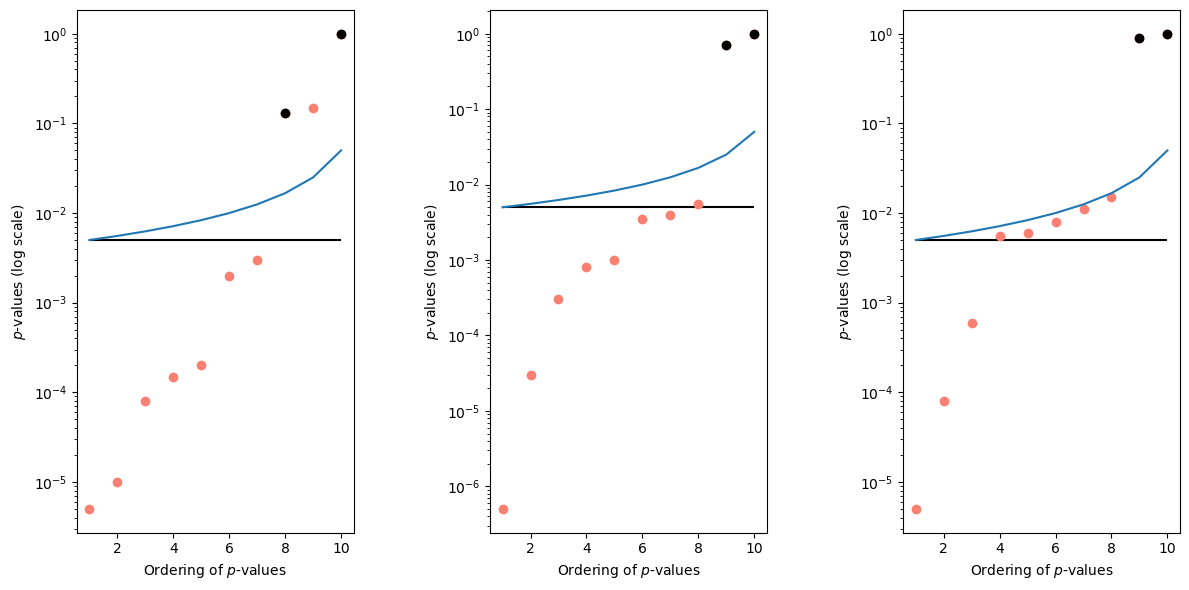

In [13]:
fig, axs = plt.subplots(1,3,figsize=(12,6))
axs = axs.flatten()

xs = np.arange(1,11)
y1 = [5e-06, 1e-05,8e-05,1.5e-04,2e-04,2e-03,3e-03,1.3e-01,1.5e-01,1]
y2 = [5e-07, 3e-05,3e-04,8e-04,1e-03,3.5e-03,4e-03,5.5e-03,7e-01,1]
y3 = [5e-06, 8e-05,6e-04,5.5e-03,6e-03,8e-03,1.1e-02,1.5e-02,9e-01,1]

y = [y1,y2,y3]

for i, ax in enumerate(axs):
    ax.hlines(0.005,1,10,'k',zorder=-1)
    ax.plot(xs,0.05/(11-xs))
    ax.scatter(xs,y[i],color='salmon')
    ax.set_xlabel('Ordering of $p$-values')
    ax.set_ylabel('$p$-values (log scale)')
    ax.set_yscale('log')

axs[0].scatter([8,10],[y1[7],y1[9]],color='k')
axs[1].scatter([9,10],[y2[8],y2[9]],color='k')
axs[2].scatter([9,10],[y3[8],y3[9]],color='k')
plt.tight_layout(w_pad=5)

```{admonition}
:class: note
(a) How many false positives, false negatives, true positives, true negatives, Type I errors, and Type II errors result from applying the Bonferroni procedure to control the FWER at level $\alpha=0.05$?

|                               | 1 | 2 | 3 |
|-------------------------------|---|---|---|
| False positive/Type I errors  | 0 | 0 | 0 |
| False negative/Type II errors | 1 | 1 | 5 |
| True positive                 | 7 | 7 | 3 |
| True negative                 | 2 | 2 | 2 |

```{admonition}
:class: note
(b) How many false positives, false negatives, true positives, true negatives, Type I errors, and Type II errors result from applying the Holm procedure to control the FWER at level $\alpha=0.05$?

|                               | 1 | 2 | 3 |
|-------------------------------|---|---|---|
| False positive/Type I errors  | 0 | 0 | 0 |
| False negative/Type II errors | 1 | 0 | 0 |
| True positive                 | 7 | 8 | 8 |
| True negative                 | 2 | 2 | 2 |

```{admonition}
:class: note
(c) What is the false discovery proportion associated with using the Bonferroni procedure to control the FWER at level $\alpha=0.05$?

There are no false positives in any panel, so the false discovery proportion is $0$.

```{admonition}
:class: note
(d) What is the false discovery proportion associated with using the Holm procedure to control the FWER at level $\alpha=0.05$?

There are no false positives in any panel, so the false discovery proportion is $0$.

```{admonition}
:class: note
(e) How would the answers to (a) and (c) change if we instead used the Bonferroni procedure to control the FWER at level $\alpha=0.001$?

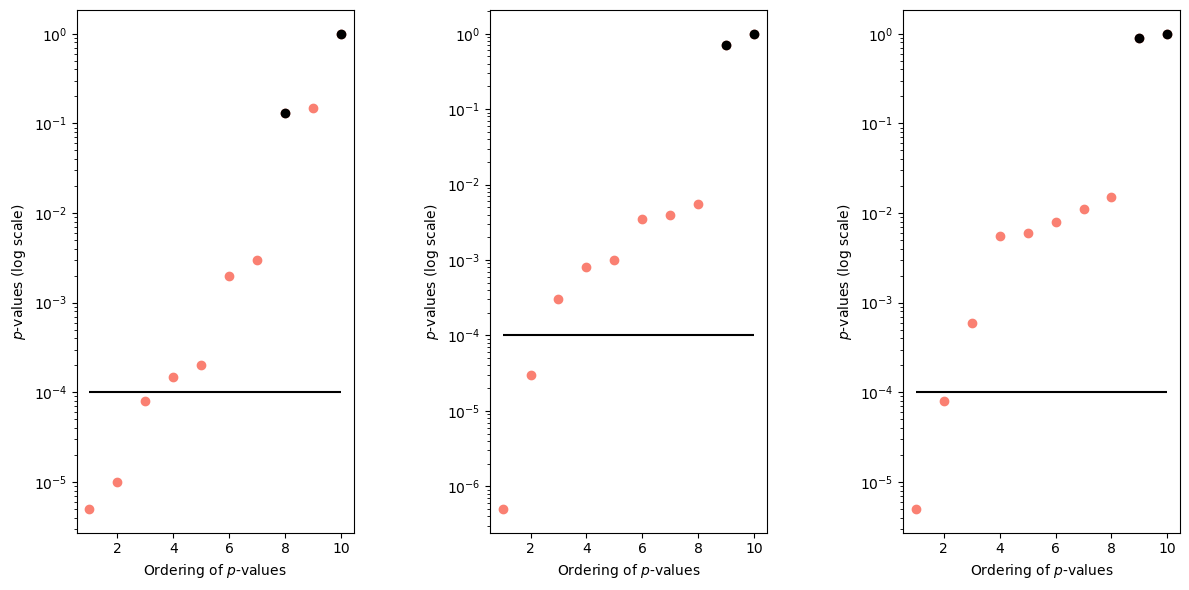

In [14]:
fig, axs = plt.subplots(1,3,figsize=(12,6))
axs = axs.flatten()

for i, ax in enumerate(axs):
    ax.hlines(0.0001,1,10,'k',zorder=-1)
    ax.scatter(xs,y[i],color='salmon')
    ax.set_xlabel('Ordering of $p$-values')
    ax.set_ylabel('$p$-values (log scale)')
    ax.set_yscale('log')

axs[0].scatter([8,10],[y1[7],y1[9]],color='k')
axs[1].scatter([9,10],[y2[8],y2[9]],color='k')
axs[2].scatter([9,10],[y3[8],y3[9]],color='k')
plt.tight_layout(w_pad=5)

|                               | 1 | 2 | 3 |
|-------------------------------|---|---|---|
| False positive/Type I errors  | 0 | 0 | 0 |
| False negative/Type II errors | 5 | 6 | 6 |
| True positive                 | 3 | 2 | 2 |
| True negative                 | 2 | 2 | 2 |

Lowering the threshold decreases the number of false positives. Therefore, there are still no false positives and the false discovery proportion is $0$.